In [84]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load data
data = load_diabetes()
X = data.data

print("Data shape:", X.shape)
print("Feature names:", data.feature_names)
print("Target shape:", data.target.shape)
print("Target values:", data.target[:10])  # Display first 10 target values

Data shape: (442, 10)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target shape: (442,)
Target values: [151.  75. 141. 206. 135.  97. 138.  63. 110. 310.]


Data shape: (1200, 2)
Target shape: (1200,)
[[ -7.85006924  -6.45406904]
 [-11.52018532   7.92164008]
 [  8.5888092    0.66601962]
 [ -6.49526677   7.51584857]
 [ -1.60570861  12.85937754]]
[2 3 1 0 0]


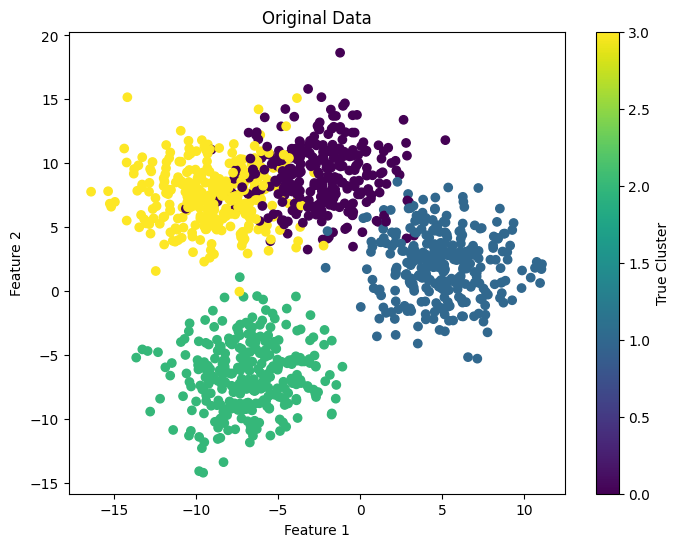

In [85]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, Y = make_blobs(
    n_samples=1200,
    centers=4,
    cluster_std=2.5,
    random_state=42
    )
print("Data shape:", X.shape)
print("Target shape:", Y.shape)
print(X[:5])  # Display first 5 samples
print(Y[:5])  # Display first 5 target values

# Visualize the original data
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=Y, cmap="viridis")
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="True Cluster")
plt.show()


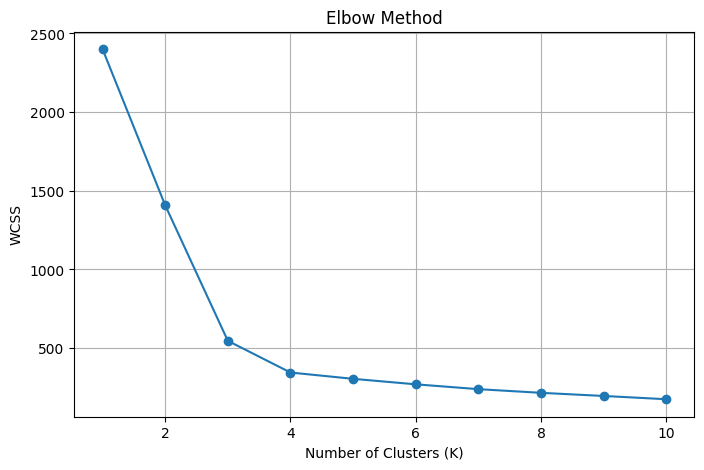

K-Means Accuracy: 0.7467
K-Means Silhouette Score: 0.5726
K-Means Adjusted Rand Index: 0.6664
K-Means Normalized Mutual Information: 0.7684


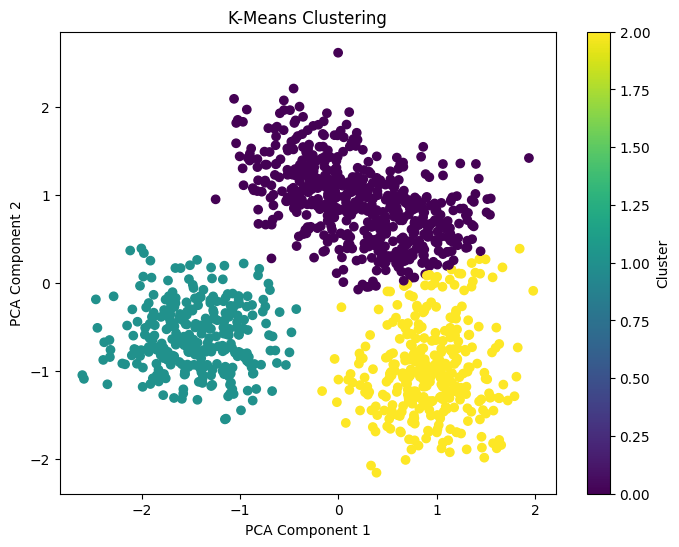

In [108]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import silhouette_score,adjusted_rand_score, normalized_mutual_info_score,accuracy_score
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np
from scipy.stats import mode   


# ==========================================
# Standardization
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ==========================================
# Elbow Method
# ==========================================

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)

plt.show()


# ==========================================
# PCA for Visualization
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


# k-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
# Fit and predict cluster labels
kmeans_labels = kmeans.fit_predict(X_scaled)
# mask label for accuracy calculation

mapped_labels = np.zeros_like(kmeans_labels)

for i in np.unique(kmeans_labels):
    mask = kmeans_labels == i
    mapped_labels[mask] = mode(Y[mask])[0]
    
accuracy = accuracy_score(Y, mapped_labels)
kmeans_score = silhouette_score(X_scaled,kmeans_labels)
kmeans_ari = adjusted_rand_score(Y,mapped_labels)
kmeans_nmi = normalized_mutual_info_score(Y,mapped_labels)
print("K-Means Accuracy:", round(accuracy,4))
print("K-Means Silhouette Score:", round(kmeans_score,4))
print("K-Means Adjusted Rand Index:", round(kmeans_ari,4))
print("K-Means Normalized Mutual Information:", round(kmeans_nmi,4))

# Hierarchical Clustering Evaluation
# print("\nHierarchical Unique Labels:")
# print(np.unique(hc_labels,
#                 return_counts=True))


plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis"
)

plt.title("K-Means Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")

plt.show()



# ==========================================
# Hierarchical Clustering
# ==========================================




Hierarchical Accuracy: 0.7433
Hierarchical Silhouette Score: 0.5738
Hierarchical Adjusted Rand Index: 0.6846
Hierarchical Normalized Mutual Information: 0.8028


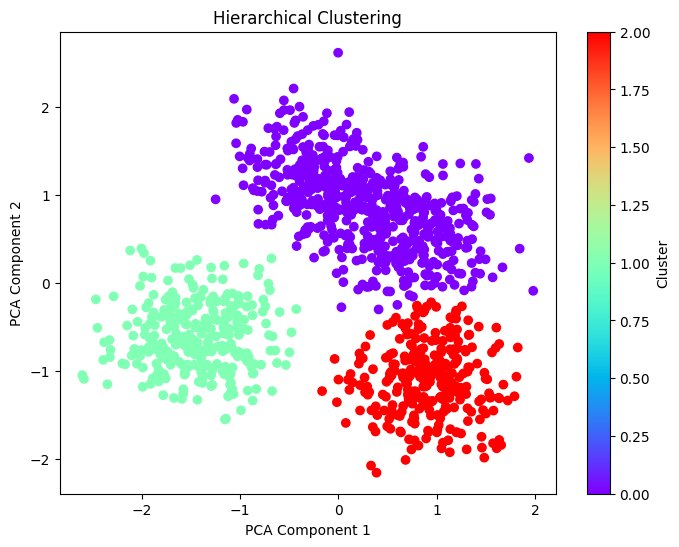

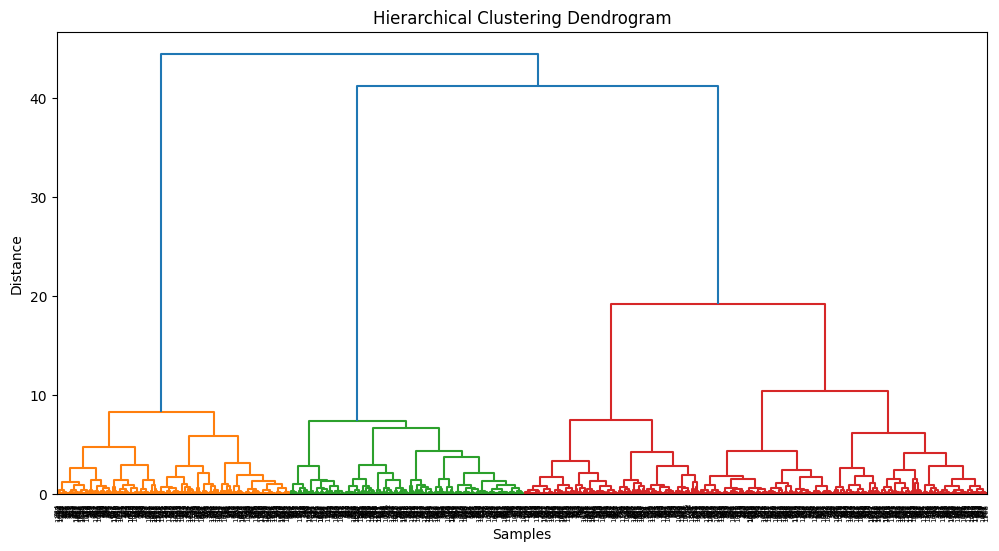

In [109]:

# Hierarchical Clustering
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
# Fit and predict cluster labels
hc_labels = hc.fit_predict(X_scaled)

mapped_labels = np.zeros_like(hc_labels)

for i in np.unique(hc_labels):
    mask = hc_labels == i
    mapped_labels[mask] = mode(Y[mask])[0]

accuracy = accuracy_score(Y, mapped_labels)
hc_score = silhouette_score(X_scaled,hc_labels)
hc_ari = adjusted_rand_score(Y,mapped_labels)
hc_nmi = normalized_mutual_info_score(Y,mapped_labels)

print("Hierarchical Accuracy:", round(accuracy,4))
print("Hierarchical Silhouette Score:",round(hc_score,4))
print("Hierarchical Adjusted Rand Index:",round(hc_ari,4))
print("Hierarchical Normalized Mutual Information:",round(hc_nmi,4))

# DBSCAN Evaluation


plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hc_labels,
    cmap="rainbow"
)

plt.title("Hierarchical Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")

plt.show()

# ==========================================
# Dendrogram
# ==========================================

Z = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()


DBSCAN Accuracy: 0.7433
DBSCAN Adjusted Rand Index: 0.5559
DBSCAN Normalized Mutual Information: 0.6199
Number of clusters: 36
Number of noise points: 144
DBSCAN Silhouette Score: -0.2017


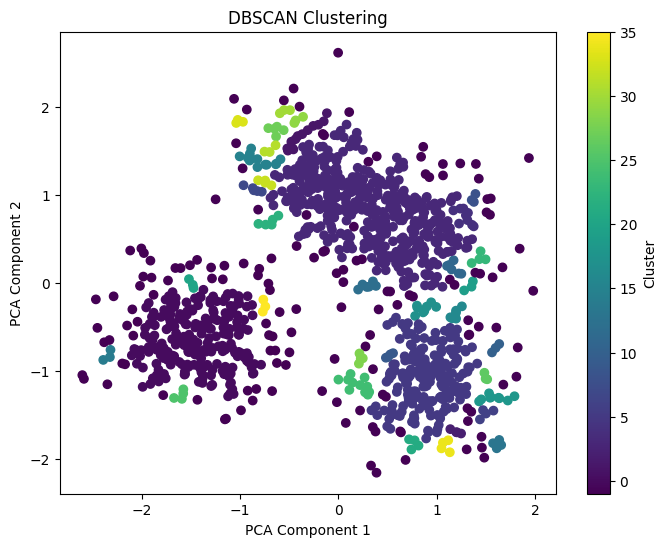

In [112]:
# DBSCAN Clustering
dbscan = DBSCAN(
    eps= 0.1,
    min_samples=3
)

# Fit and predict cluster labels
dbscan_labels = dbscan.fit_predict(X_scaled)

mapped_labels = np.zeros_like(dbscan_labels)

for i in np.unique(dbscan_labels):
    mask = dbscan_labels == i
    mapped_labels[mask] = mode(Y[mask])[0]

acuracy = accuracy_score(Y, mapped_labels)
dbscan_ari = adjusted_rand_score(Y,mapped_labels)
dbscan_nmi = normalized_mutual_info_score(Y,mapped_labels)
print("DBSCAN Accuracy:", round(accuracy,4))
print("DBSCAN Adjusted Rand Index:", round(dbscan_ari,4))
print("DBSCAN Normalized Mutual Information:", round(dbscan_nmi,4))


n_clusters = len(
    set(dbscan_labels)
) - (1 if -1 in dbscan_labels else 0)

n_noise = list(
    dbscan_labels
).count(-1)

print("Number of clusters:",n_clusters)

print("Number of noise points:",n_noise)


if n_clusters > 1:

    dbscan_score = silhouette_score(
        X_scaled,
        dbscan_labels
    )

    print("DBSCAN Silhouette Score:",
          round(dbscan_score,4))

else:

    print("Silhouette Score cannot be computed.")



plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    cmap="viridis"
)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


K=1, BIC=6844.57
K=2, BIC=5922.80
K=3, BIC=5496.90
K=4, BIC=5529.38
K=5, BIC=5520.68
Gaussian Mixture Accuracy: 0.7433


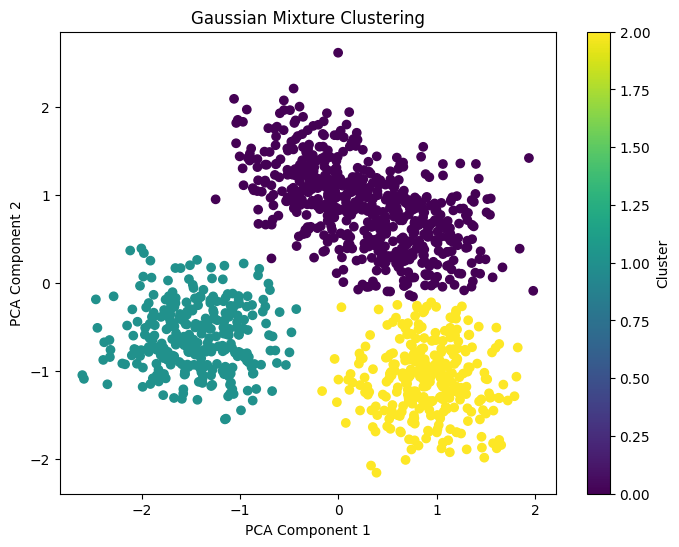

In [111]:
from sklearn.mixture import GaussianMixture


bics = []

for k in range(1, 6):   # 1 to 5
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )
    
    gmm.fit(X_scaled)
    
    bic = gmm.bic(X_scaled)
    bics.append(bic)
    
    print(f"K={k}, BIC={bic:.2f}")

best_k = np.argmin(bics) + 1
# Gaussian Mixture Model
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

labels = gmm.fit_predict(X_scaled)

mapped_labels = np.zeros_like(labels)
for i in np.unique(labels):
    mask = labels == i
    mapped_labels[mask] = mode(Y[mask])[0]

accuracy = accuracy_score(Y, mapped_labels)
print("Gaussian Mixture Accuracy:", round(accuracy,4))

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis'
)

plt.title("Gaussian Mixture Clustering")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.colorbar(label='Cluster')

plt.show()